In [ ]:
# 1. Install required libraries (run once)
!pip install -q transformers datasets evaluate accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.0 MB/s eta 0:00:00


In [ ]:
# 2. Imports
import torch
import numpy as np
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)
import evaluate
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

GPU: Tesla T4


In [ ]:
# 3. Load dataset
dataset = load_dataset("dair-ai/emotion")
print(dataset)
print("Classes:", dataset["train"].features["label"].names)
print("Example:", dataset["train"][0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})
Classes: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
Example: {'text': 'i didnt feel humiliated', 'label': 0}


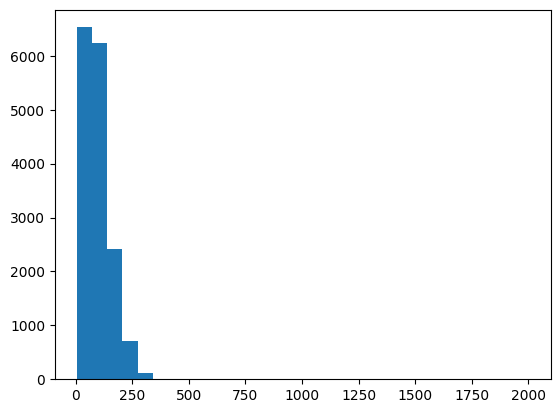

In [ ]:
import matplotlib.pyplot as plt

lengths = dataset["train"][:]['text']
lengths.append(dataset["test"][:]['text'])
lengths.append(dataset["validation"][:]['text'])
plt.hist([len(x) for x in lengths], bins=30)
plt.show()

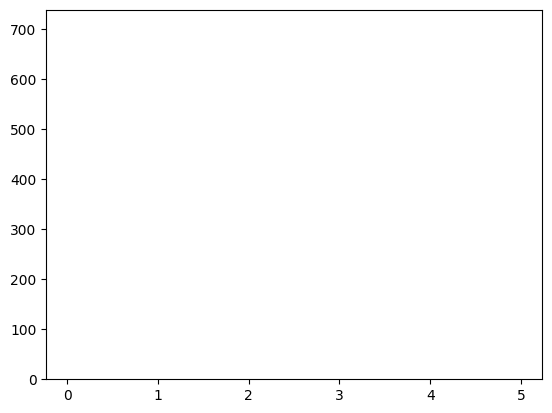

In [ ]:
# see the distribution of classes in all sets combined

labels = dataset["train"][:]['label']
labels.extend(dataset["test"][:]['label'])
labels.extend(dataset["validation"][:]['label'])
plt.hist(labels, bins=np.arange(-0.5, 6.5, 1))
plt.xticks(np.arange(6), dataset["train"].features["label"].names)
plt.show()

In [ ]:
model_checkpoint = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

def preprocess(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=300
    )

tokenized_dataset = dataset.map(
    preprocess,
    batched=True,
    remove_columns=["text"]   # remove during mapping
)

tokenized_dataset = tokenized_dataset.rename_column("label", "labels")

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
tokenized_dataset

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})

In [ ]:
# 5. Load model with classification head
labels_name =dataset["train"].features["label"].names
num_labels = len(labels_name)
id2label = {i: name for i, name in enumerate(labels_name)}
label2id = {name: i for i, name in id2label.items()}

model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)
model.to(torch.device("cuda" if torch.cuda.is_available() else "cpu"))

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [ ]:
# 6. Metrics
accuracy = evaluate.load("accuracy")
f1 = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy.compute(predictions=predictions, references=labels)["accuracy"]
    f1_score = f1.compute(predictions=predictions, references=labels, average="weighted")["f1"]
    return {"accuracy": acc, "f1": f1_score}

In [ ]:
# 7. Training arguments
training_args = TrainingArguments(
    output_dir="./emotion_model",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=4,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=50,
    report_to="none"
)

In [ ]:
# 8. Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

In [ ]:
# 9. Train
trainer.train()



Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.253013,0.196914,0.926000,0.927021
2,0.161508,0.161057,0.931500,0.930967
3,0.098076,0.160275,0.939000,0.939451
4,0.049335,0.158888,0.944000,0.943943


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=4000, training_loss=0.20568727719783783, metrics={'train_runtime': 367.1762, 'train_samples_per_second': 174.303, 'train_steps_per_second': 10.894, 'total_flos': 779286779309952.0, 'train_loss': 0.20568727719783783, 'epoch': 4.0})

In [ ]:
# 10. Evaluate on test set
test_results = trainer.evaluate(tokenized_dataset["test"])
print(test_results)



{'eval_loss': 0.18920627236366272, 'eval_accuracy': 0.924, 'eval_f1': 0.9237253665383601, 'eval_runtime': 3.3824, 'eval_samples_per_second': 591.305, 'eval_steps_per_second': 36.957, 'epoch': 4.0}


In [ ]:
# 11. Save model and tokenizer
save_path = "..\saved_models\emotion_distilbert_finetuned"
trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./emotion_distilbert_finetuned/tokenizer_config.json',
 './emotion_distilbert_finetuned/tokenizer.json')

In [ ]:

# 12. Zip and download
# !zip -r emotion_model.zip ./emotion_distilbert_finetuned
# from google.colab import files
# # files.download("emotion_model.zip")

  adding: emotion_distilbert_finetuned/ (stored 0%)
  adding: emotion_distilbert_finetuned/training_args.bin (deflated 53%)
  adding: emotion_distilbert_finetuned/config.json (deflated 52%)
  adding: emotion_distilbert_finetuned/tokenizer_config.json (deflated 42%)
  adding: emotion_distilbert_finetuned/model.safetensors (deflated 8%)
  adding: emotion_distilbert_finetuned/tokenizer.json (deflated 71%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>